In [16]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [17]:
# Project and dataset paths

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Garbage_Dataset_Classification"
    / "images"
)

print("Dataset path:")
print(DATASET_DIR)

print("\nDataset exists:", DATASET_DIR.exists())

Dataset path:
d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\data\raw\Garbage_Dataset_Classification\images

Dataset exists: True


In [18]:
# Waste classification categories

CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

print("Classes:")
for index, class_name in enumerate(CLASSES):
    print(f"{index}: {class_name}")

Classes:
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


In [19]:
image_records = []

for label, class_name in enumerate(CLASSES):

    class_dir = DATASET_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.is_file():

            image_records.append({
                "image_path": str(image_path),
                "class": class_name,
                "label": label
            })


# Convert list of dictionaries into a DataFrame
df = pd.DataFrame(image_records)

print("Total images:", len(df))

print("\nDataset preview:")
display(df.head())

Total images: 13901

Dataset preview:


,image_path,class,label
0,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,cardboard,0
1,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,cardboard,0
2,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,cardboard,0
3,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,cardboard,0
4,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,cardboard,0


In [5]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape:
(13901, 3)

Column names:
['image_path', 'class', 'label']

Data types:
image_path      str
class           str
label         int64
dtype: object


In [20]:
class_counts = (
    df["class"]
    .value_counts()
    .reindex(CLASSES)
)

print("Images per class:")
print(class_counts)

Images per class:
class
cardboard    2214
glass        2500
metal        2084
paper        2315
plastic      2288
trash        2500
Name: count, dtype: int64


In [7]:
class_percentages = (
    class_counts / len(df) * 100
)

class_distribution = pd.DataFrame({
    "Image Count": class_counts,
    "Percentage": class_percentages.round(2)
})

display(class_distribution)

,Image Count,Percentage
class,,
cardboard,2214,15.93
glass,2500,17.98
metal,2084,14.99
paper,2315,16.65
plastic,2288,16.46
trash,2500,17.98


In [8]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest class:", largest_class)
print("Smallest class:", smallest_class)
print(f"Imbalance ratio: {imbalance_ratio:.3f}:1")

Largest class: 2500
Smallest class: 2084
Imbalance ratio: 1.200:1


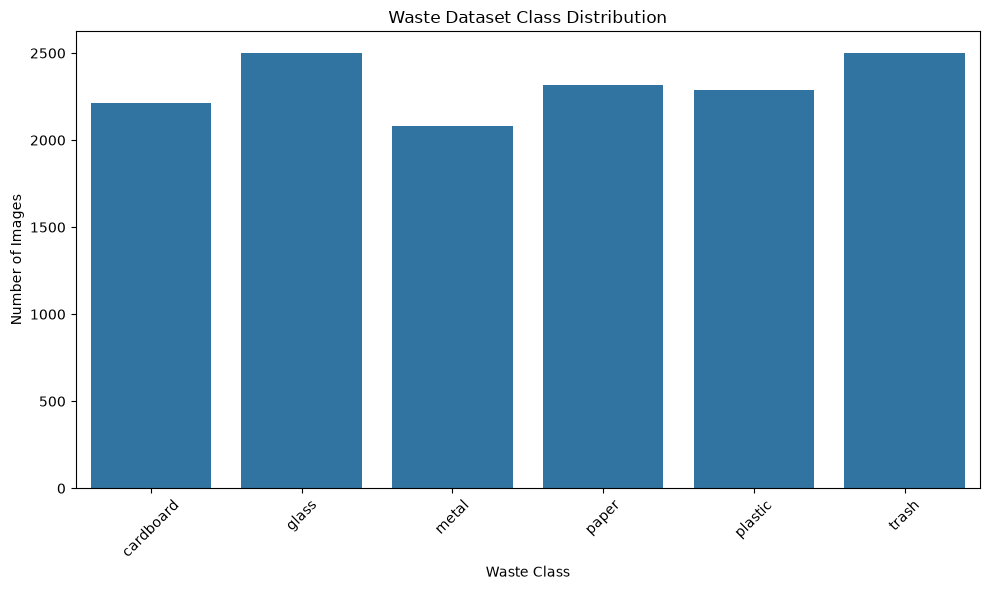

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Waste Dataset Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
image_properties = []

for image_path in df["image_path"]:

    try:

        with Image.open(image_path) as img:

            image_properties.append({
                "image_path": image_path,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

    except Exception as e:

        image_properties.append({
            "image_path": image_path,
            "width": None,
            "height": None,
            "mode": "ERROR"
        })


image_properties_df = pd.DataFrame(image_properties)

In [11]:
print("Most common image dimensions:")

print(
    image_properties_df[
        ["width", "height"]
    ]
    .value_counts()
    .head(20)
)

Most common image dimensions:
width  height
256    256       13901
Name: count, dtype: int64


In [12]:
print("Image color modes:")

print(
    image_properties_df["mode"]
    .value_counts()
)

Image color modes:
mode
RGB    13901
Name: count, dtype: int64


In [13]:
corrupted_images = []

for image_path in df["image_path"]:

    try:

        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:

        corrupted_images.append({
            "image_path": image_path,
            "error": str(e)
        })


print(
    "Number of corrupted/unreadable images:",
    len(corrupted_images)
)

Number of corrupted/unreadable images: 0


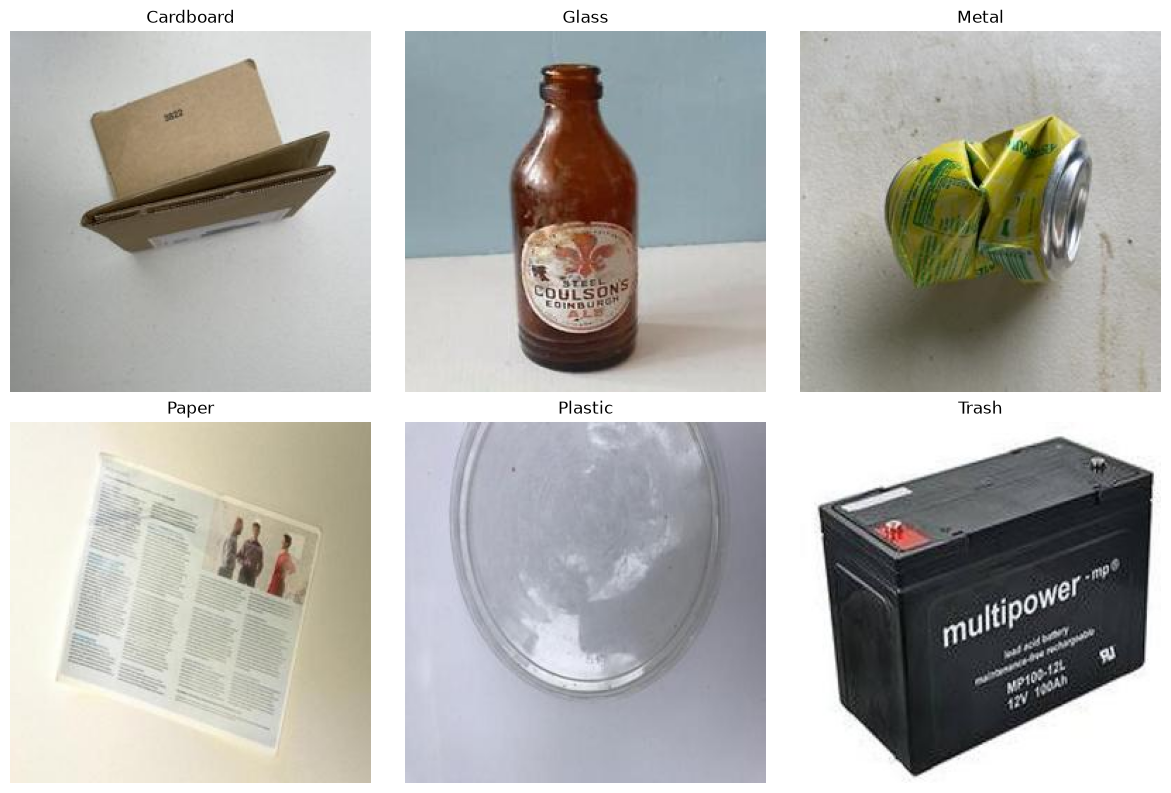

In [14]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, class_name in zip(axes.flat, CLASSES):

    class_images = df[
        df["class"] == class_name
    ]

    sample = class_images.sample(
        1,
        random_state=RANDOM_SEED
    ).iloc[0]

    image = Image.open(sample["image_path"])

    ax.imshow(image)
    ax.set_title(class_name.capitalize())
    ax.axis("off")


plt.tight_layout()
plt.show()

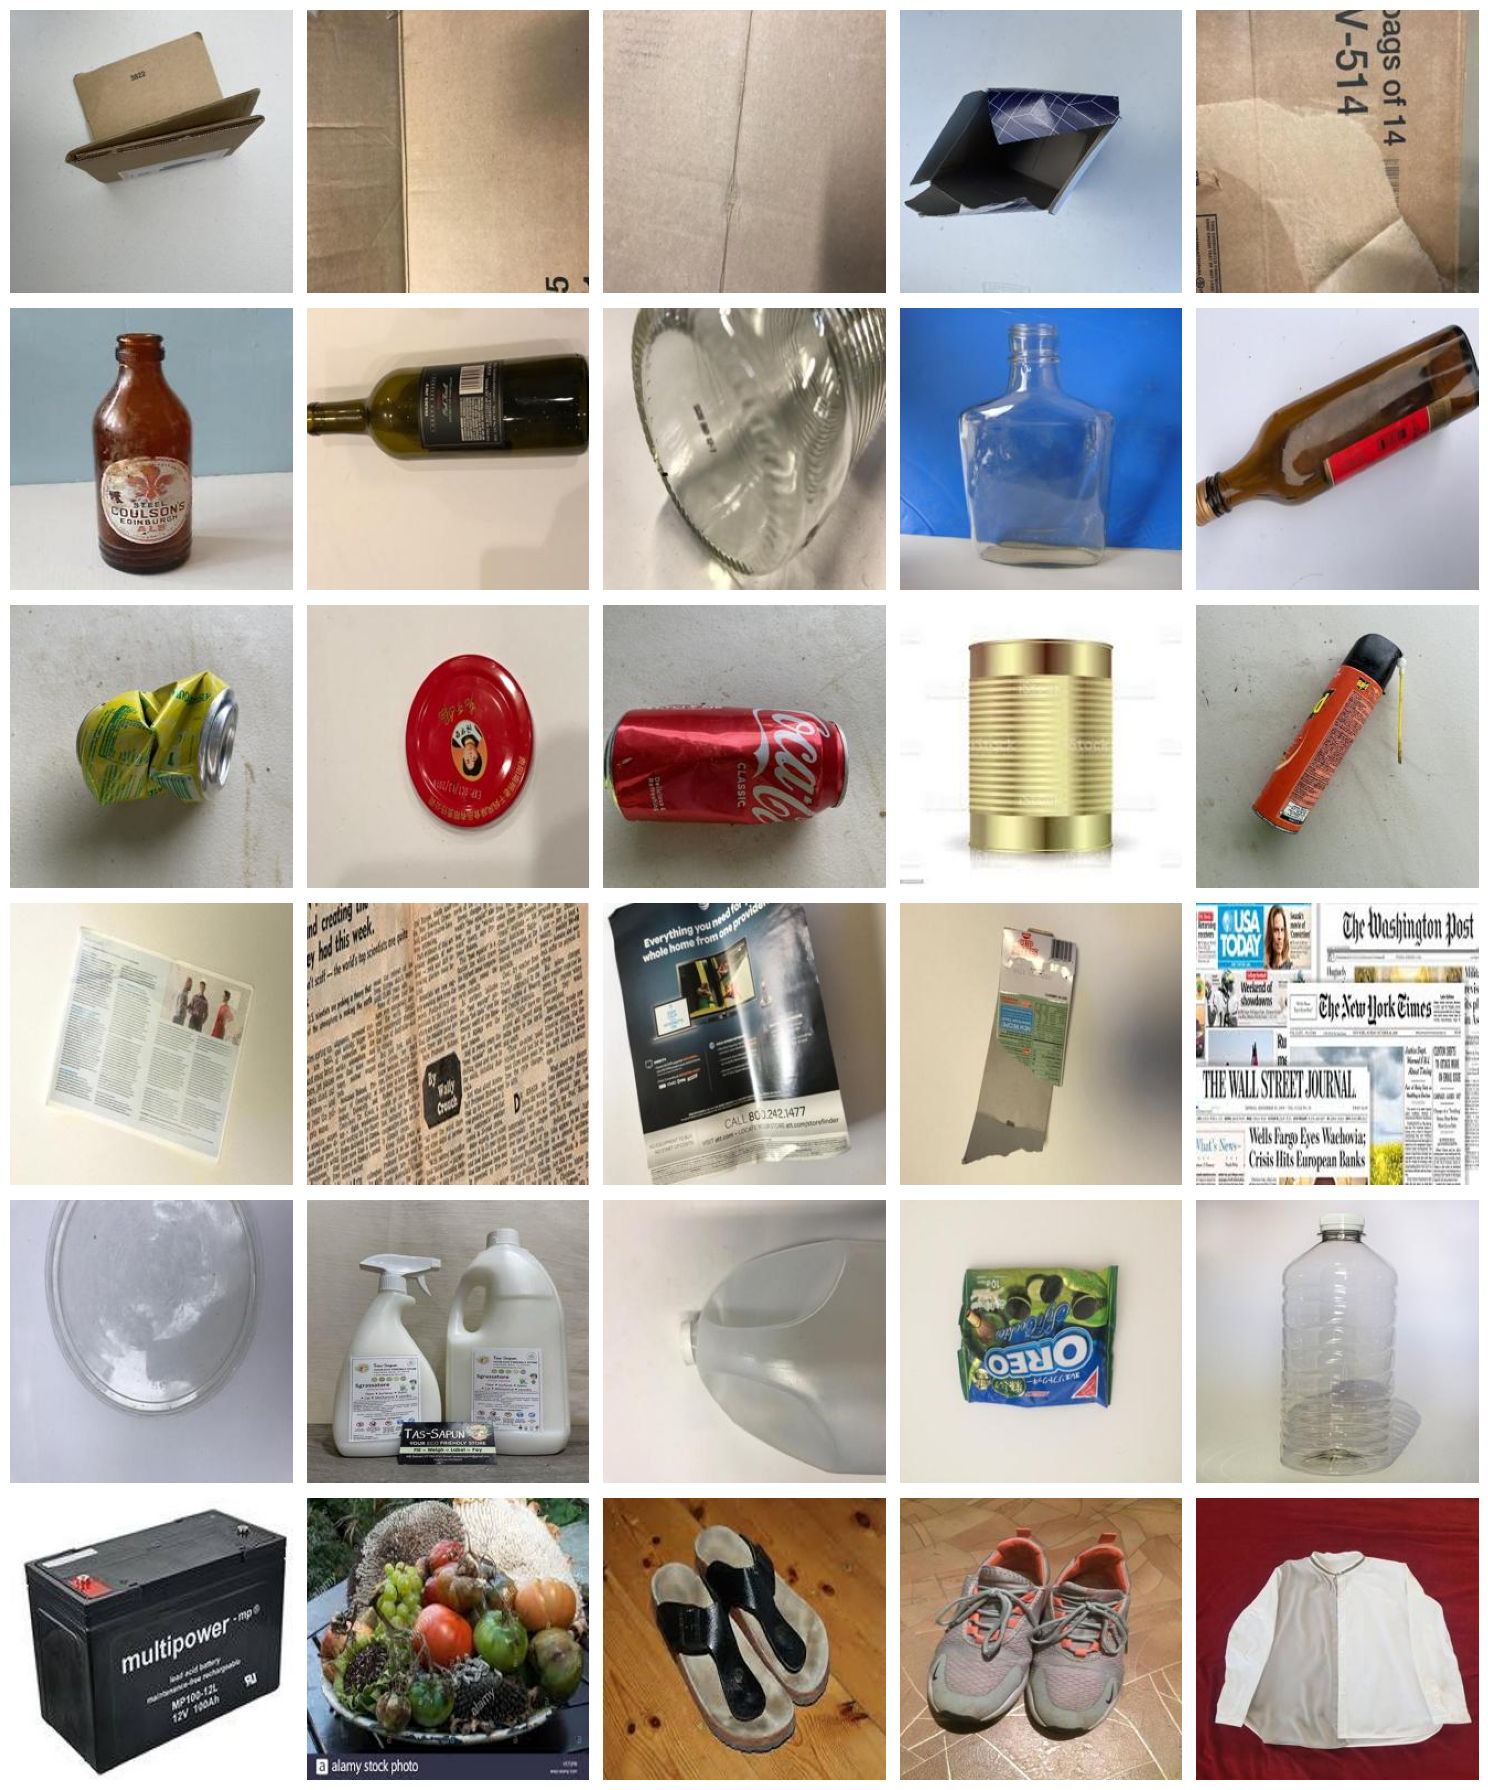

In [15]:
fig, axes = plt.subplots(
    len(CLASSES),
    5,
    figsize=(15, 18)
)

for row, class_name in enumerate(CLASSES):

    class_images = df[
        df["class"] == class_name
    ]

    samples = class_images.sample(
        5,
        random_state=RANDOM_SEED
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["image_path"])

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                class_name.capitalize(),
                fontsize=12
            )


plt.tight_layout()
plt.show()

In [21]:
import hashlib

In [22]:
def calculate_file_hash(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as file:

        for chunk in iter(lambda: file.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()

In [23]:
df["file_hash"] = df["image_path"].apply(
    calculate_file_hash
)

print("Hash calculation completed.")

Hash calculation completed.


In [24]:
duplicate_images = df[
    df["file_hash"].duplicated(keep=False)
].sort_values("file_hash")

print(
    "Number of images involved in exact duplicates:",
    len(duplicate_images)
)

Number of images involved in exact duplicates: 4488


In [25]:
total_images = len(df)
unique_images = df["file_hash"].nunique()
duplicate_files = total_images - unique_images

print("Total image files:", total_images)
print("Unique image contents:", unique_images)
print("Duplicate files beyond the first copy:", duplicate_files)

Total image files: 13901
Unique image contents: 11657
Duplicate files beyond the first copy: 2244


In [26]:
duplicate_class_analysis = (
    duplicate_images
    .groupby("file_hash")["class"]
    .nunique()
)

cross_class_duplicates = (
    duplicate_class_analysis > 1
).sum()

same_class_duplicate_groups = (
    duplicate_class_analysis == 1
).sum()

print("Duplicate hash groups:", len(duplicate_class_analysis))
print("Duplicate groups across multiple classes:", cross_class_duplicates)
print("Duplicate groups within the same class:", same_class_duplicate_groups)

Duplicate hash groups: 2244
Duplicate groups across multiple classes: 2
Duplicate groups within the same class: 2242


In [27]:
cross_class_hashes = duplicate_class_analysis[
    duplicate_class_analysis > 1
].index

cross_class_duplicates_df = duplicate_images[
    duplicate_images["file_hash"].isin(cross_class_hashes)
].sort_values("file_hash")

display(
    cross_class_duplicates_df[
        ["image_path", "class", "label", "file_hash"]
    ]
)

,image_path,class,label,file_hash
5254,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,metal,2,5a2f6db83f98cad4247b89690da56f6b
2366,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,glass,1,5a2f6db83f98cad4247b89690da56f6b
3411,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,glass,1,9b75711b9433ad9f93b7c3cf3cdc2694
9376,d:\Accademic\SLIIT\4 Year\Deep Learning\Assing...,plastic,4,9b75711b9433ad9f93b7c3cf3cdc2694


In [28]:
# Create a duplicate group ID based on the image hash

df["duplicate_group"] = (
    df["file_hash"]
    .factorize()[0]
)

print("Number of duplicate groups:",
      df["duplicate_group"].nunique())

Number of duplicate groups: 11657


In [29]:
# Identify hashes that appear under more than one class

duplicate_class_counts = (
    df.groupby("file_hash")["class"]
    .nunique()
)

conflicting_hashes = duplicate_class_counts[
    duplicate_class_counts > 1
].index

print("Conflicting duplicate groups:",
      len(conflicting_hashes))

Conflicting duplicate groups: 2


In [30]:
df_clean = df[
    ~df["file_hash"].isin(conflicting_hashes)
].copy()

print("Original images:", len(df))
print("Clean images:", len(df_clean))
print(
    "Removed images:",
    len(df) - len(df_clean)
)

Original images: 13901
Clean images: 13897
Removed images: 4


In [31]:
clean_class_counts = (
    df_clean["class"]
    .value_counts()
    .reindex(CLASSES)
)

print("Images per class after cleaning:")
print(clean_class_counts)

Images per class after cleaning:
class
cardboard    2214
glass        2498
metal        2083
paper        2315
plastic      2287
trash        2500
Name: count, dtype: int64


In [32]:
clean_class_percentages = (
    clean_class_counts / len(df_clean) * 100
)

clean_class_distribution = pd.DataFrame({
    "Image Count": clean_class_counts,
    "Percentage": clean_class_percentages.round(2)
})

display(clean_class_distribution)

,Image Count,Percentage
class,,
cardboard,2214,15.93
glass,2498,17.98
metal,2083,14.99
paper,2315,16.66
plastic,2287,16.46
trash,2500,17.99


In [ ]:
duplicate_group_sizes = (
    df_clean
    .groupby("file_hash")
    .size()
    .value_counts()
    .sort_index()
)

print("Duplicate group size distribution:")
print(duplicate_group_sizes)



Duplicate group size distribution:
1    9413
2    2242
Name: count, dtype: int64


In [37]:
group_df = (
    df_clean
    .groupby("file_hash")
    .agg({
        "class": "first",
        "label": "first"
    })
    .reset_index()
)

# Count how many files belong to each duplicate group
group_sizes = (
    df_clean
    .groupby("file_hash")
    .size()
    .reset_index(name="image_count")
)

# Add group size information
group_df = group_df.merge(
    group_sizes,
    on="file_hash"
)

print("Number of unique image groups:", len(group_df))

print("\nGroup size distribution:")
print(
    group_df["image_count"]
    .value_counts()
    .sort_index()
)

Number of unique image groups: 11655

Group size distribution:
image_count
1    9413
2    2242
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split

In [39]:
train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=group_df["label"]
)

print("Training groups:", len(train_groups))
print("Temporary groups:", len(temp_groups))

Training groups: 8158
Temporary groups: 3497


In [40]:
validation_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_groups["label"]
)

print("Training groups:", len(train_groups))
print("Validation groups:", len(validation_groups))
print("Test groups:", len(test_groups))

Training groups: 8158
Validation groups: 1748
Test groups: 1749


In [41]:
train_hashes = set(train_groups["file_hash"])
validation_hashes = set(validation_groups["file_hash"])
test_hashes = set(test_groups["file_hash"])

print("Train hash groups:", len(train_hashes))
print("Validation hash groups:", len(validation_hashes))
print("Test hash groups:", len(test_hashes))

Train hash groups: 8158
Validation hash groups: 1748
Test hash groups: 1749


In [42]:
df_clean["split"] = df_clean["file_hash"].apply(
    lambda x:
        "train" if x in train_hashes
        else "validation" if x in validation_hashes
        else "test"
)

In [43]:
print("Image files per split:")
print(df_clean["split"].value_counts())

Image files per split:
split
train         9692
validation    2114
test          2091
Name: count, dtype: int64


In [44]:
hash_split_counts = (
    df_clean
    .groupby("file_hash")["split"]
    .nunique()
)

leaked_groups = (
    hash_split_counts > 1
).sum()

print(
    "Duplicate groups appearing in multiple splits:",
    leaked_groups
)

Duplicate groups appearing in multiple splits: 0


In [45]:
split_class_counts = pd.crosstab(
    df_clean["class"],
    df_clean["split"]
)

display(split_class_counts)

split,test,train,validation
class,,,
cardboard,344,1548,322
glass,367,1751,380
metal,317,1440,326
paper,346,1605,364
plastic,342,1598,347
trash,375,1750,375


In [46]:
split_class_percentages = (
    pd.crosstab(
        df_clean["class"],
        df_clean["split"],
        normalize="columns"
    ) * 100
)

display(
    split_class_percentages.round(2)
)

split,test,train,validation
class,,,
cardboard,16.45,15.97,15.23
glass,17.55,18.07,17.98
metal,15.16,14.86,15.42
paper,16.55,16.56,17.22
plastic,16.36,16.49,16.41
trash,17.93,18.06,17.74


In [47]:
all_splits_df = df_clean.copy()

all_splits_df["relative_path"] = all_splits_df["image_path"].apply(
    lambda x: str(
        Path(x).resolve().relative_to(DATASET_DIR.resolve())
    ).replace("\\", "/")
)

display(
    all_splits_df[
        ["relative_path", "class", "label", "split"]
    ].head()
)

,relative_path,class,label,split
0,cardboard/cardboard_00001.jpg,cardboard,0,train
1,cardboard/cardboard_00002.jpg,cardboard,0,test
2,cardboard/cardboard_00003.jpg,cardboard,0,validation
3,cardboard/cardboard_00007.jpg,cardboard,0,train
4,cardboard/cardboard_00010.jpg,cardboard,0,validation


In [48]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed directory:", PROCESSED_DIR)

Processed directory: d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\data\processed


In [49]:
train_export = all_splits_df[
    all_splits_df["split"] == "train"
][
    ["relative_path", "class", "label"]
]

validation_export = all_splits_df[
    all_splits_df["split"] == "validation"
][
    ["relative_path", "class", "label"]
]

test_export = all_splits_df[
    all_splits_df["split"] == "test"
][
    ["relative_path", "class", "label"]
]

In [50]:
train_export.to_csv(
    PROCESSED_DIR / "train.csv",
    index=False
)

validation_export.to_csv(
    PROCESSED_DIR / "validation.csv",
    index=False
)

test_export.to_csv(
    PROCESSED_DIR / "test.csv",
    index=False
)

print("Train, validation, and test CSV files saved successfully.")

Train, validation, and test CSV files saved successfully.
